In [1]:
!pip install pandas
!pip install polars
!pip install dask
!pip install pyarrow
!pip install duckdb

In [2]:
import duckdb
con = duckdb.connect()

df = con.execute("""
SELECT 
    h.county,
    h.date,
    h.cases,
    a.avg_aqi,
    e.avg_temp,
    e.avg_precip
FROM 'health_agg.parquet' h
LEFT JOIN 'aqi_agg.parquet' a
    ON h.county = a.county AND h.date = a.date
LEFT JOIN 'era5_agg.parquet' e
    ON h.county = e.county AND h.date = e.date
""").df()

print(df.head())
print(df.shape)

      county       date  cases  avg_aqi  avg_temp    avg_precip
0      macon 2017-01-05     10     28.0   -9.5286  7.430535e-05
1      edgar 2017-01-06      2     48.0  -13.5830  2.638071e-07
2  champaign 2017-01-07      7     52.0  -14.0041 -2.321105e-09
3  vermilion 2017-01-08      6     33.0  -11.7825 -8.874443e-10
4   iroquois 2017-01-14      1     60.0   -1.6437  2.727814e-05
(21416, 6)


In [3]:
print(df.isna().sum())

county        0
date          0
cases         0
avg_aqi       0
avg_temp      0
avg_precip    0
dtype: int64


In [4]:
import pandas as pd

df['date'] = pd.to_datetime(df['date'])

monthly = df.groupby([
    'county',
    df['date'].dt.year.rename('year'),
    df['date'].dt.month.rename('month')
]).agg({
    'cases':'sum',
    'avg_aqi':'mean',
    'avg_temp':'mean',
    'avg_precip':'mean'
}).reset_index()

In [5]:
monthly[['cases','avg_aqi','avg_temp','avg_precip']].corr()

,cases,avg_aqi,avg_temp,avg_precip
cases,1.000000,0.106760,-0.058841,-0.011104
avg_aqi,0.106760,1.000000,0.353609,-0.079373
avg_temp,-0.058841,0.353609,1.000000,0.156836
avg_precip,-0.011104,-0.079373,0.156836,1.000000


In [6]:
monthly.groupby('month')['cases'].mean()

month
1     54.120000
2     47.236220
3     50.692913
4     43.039683
5     46.564516
6     38.200000
7     37.204724
8     44.476190
9     51.720000
10    56.888889
11    52.897638
12    52.039062
Name: cases, dtype: float64

In [7]:
monthly.groupby('county')['cases'].sum().sort_values(ascending=False)

county
macon         18590
champaign     18153
mclean        10773
vermilion     10488
shelby         2498
coles          2232
livingston     2142
iroquois       1588
dewitt         1132
piatt          1027
moultrie        853
douglas         807
cumberland      733
ford            654
edgar           543
clark           302
Name: cases, dtype: int64

  Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 64.2 MB/s  0:00:00
Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (5.0 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (1.5 MB)
Using cached pi

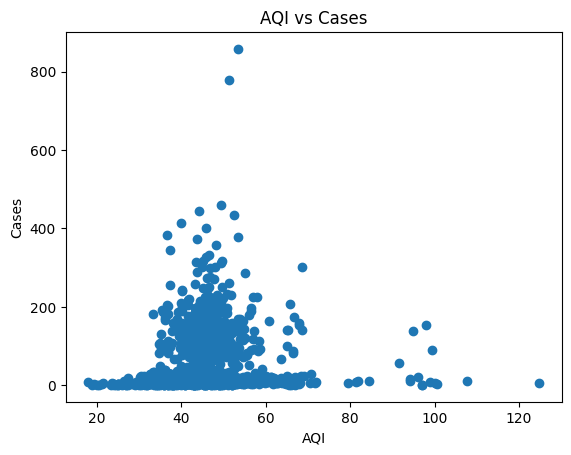

In [8]:
!pip install matplotlib
import matplotlib.pyplot as plt

plt.scatter(monthly['avg_aqi'], monthly['cases'])
plt.xlabel("AQI")
plt.ylabel("Cases")
plt.title("AQI vs Cases")
plt.show()

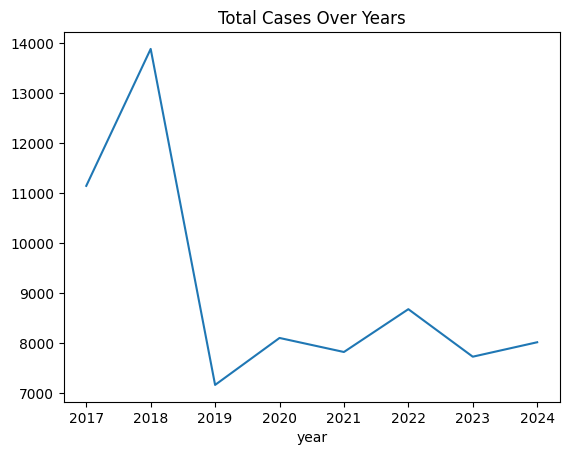

In [9]:
import matplotlib.pyplot as plt

monthly.groupby('year')['cases'].sum().plot()
plt.title("Total Cases Over Years")
plt.show()

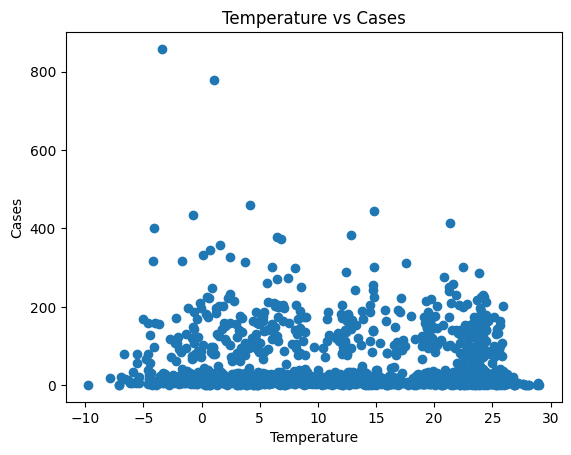

In [10]:
plt.scatter(monthly['avg_temp'], monthly['cases'])
plt.xlabel("Temperature")
plt.ylabel("Cases")
plt.title("Temperature vs Cases")
plt.show()

In [11]:
#FOR AASTHMA 

asthma_county = con.execute("""
SELECT 
    LOWER(REPLACE(TRIM(Region), ' ', '')) AS county,
    COUNT(*) AS asthma_cases
FROM 'master_filtered.parquet'
WHERE LOWER(CCDDCategory_flat) LIKE '%asthma%'
GROUP BY county
ORDER BY asthma_cases DESC
""").df()

print(asthma_county)

        county  asthma_cases
0        macon         18590
1    champaign         18153
2       mclean         10773
3    vermilion         10488
4       shelby          2498
5        coles          2232
6   livingston          2142
7     iroquois          1588
8       dewitt          1132
9        piatt          1027
10    moultrie           853
11     douglas           807
12  cumberland           733
13        ford           654
14       edgar           543
15       clark           302


In [12]:
asthma_year = con.execute("""
SELECT 
    LOWER(REPLACE(TRIM(Region), ' ', '')) AS county,
    CAST(STRPTIME(Date, '%m/%d/%Y') AS DATE) AS date
FROM 'master_filtered.parquet'
WHERE LOWER(CCDDCategory_flat) LIKE '%asthma%'
""").df()

import pandas as pd

asthma_year['year'] = pd.to_datetime(asthma_year['date']).dt.year

asthma_year.groupby(['county','year']).size().reset_index(name='cases')

,county,year,cases
0,champaign,2017,2559
1,champaign,2018,3778
2,champaign,2019,1997
3,champaign,2020,1663
4,champaign,2021,1717
...,...,...,...
123,vermilion,2020,995
124,vermilion,2021,1017
125,vermilion,2022,1740
126,vermilion,2023,1174


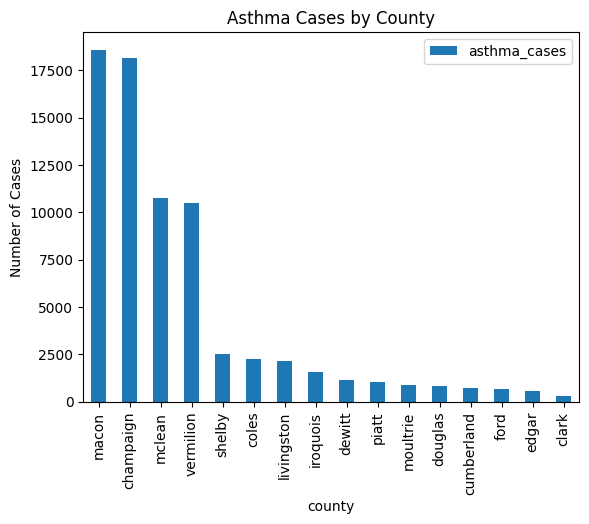

In [13]:
import matplotlib.pyplot as plt

asthma_county.set_index('county').plot(kind='bar')
plt.title("Asthma Cases by County")
plt.ylabel("Number of Cases")
plt.show()

In [14]:
asthma_df = con.execute("""
SELECT 
    LOWER(REPLACE(TRIM(Region), ' ', '')) AS county,
    STRPTIME(Date, '%m/%d/%Y') AS date
FROM 'master_filtered.parquet'
WHERE LOWER(CCDDCategory_flat) LIKE '%asthma%'
""").df()

In [15]:
asthma_daily = asthma_df.groupby(['county','date']).size().reset_index(name='asthma_cases')

In [16]:
aqi_df = con.execute("""
SELECT 
    LOWER(REPLACE(TRIM(region), ' ', '')) AS county,
    climate_date AS date,
    AQI
FROM 'aqi_filtered.parquet'
WHERE Was_Interpolated = FALSE
""").df()

merged = asthma_daily.merge(aqi_df, on=['county','date'], how='left')

In [17]:
print(merged.isna().sum())

county              0
date                0
asthma_cases        0
AQI             12654
dtype: int64


In [18]:
merged['date'] = pd.to_datetime(merged['date'])

monthly = merged.groupby([
    'county',
    merged['date'].dt.year.rename('year'),
    merged['date'].dt.month.rename('month')
]).agg({
    'asthma_cases':'sum',
    'AQI':'mean'
}).reset_index()

In [19]:
monthly[['asthma_cases','AQI']].corr()

,asthma_cases,AQI
asthma_cases,1.000000,0.290161
AQI,0.290161,1.000000


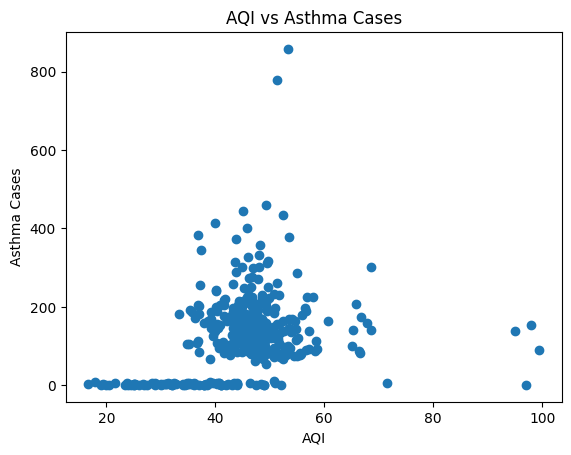

In [20]:
import matplotlib.pyplot as plt

plt.scatter(monthly['AQI'], monthly['asthma_cases'])
plt.xlabel("AQI")
plt.ylabel("Asthma Cases")
plt.title("AQI vs Asthma Cases")
plt.show()

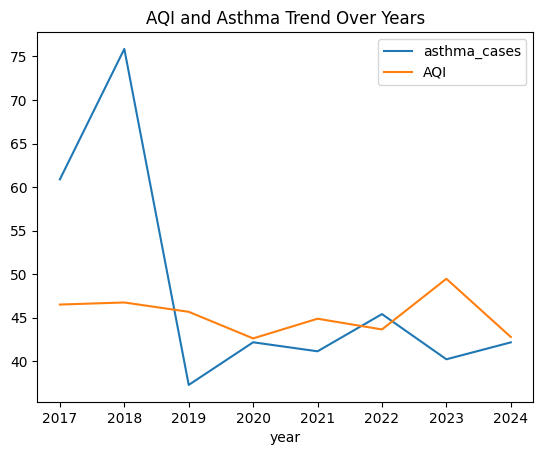

In [21]:
monthly.groupby('year')[['asthma_cases','AQI']].mean().plot()
plt.title("AQI and Asthma Trend Over Years")
plt.show()

In [31]:
copd_df = con.execute("""
SELECT 
    LOWER(REPLACE(TRIM(Region), ' ', '')) AS county,
    STRPTIME(Date, '%m/%d/%Y') AS date
FROM 'master_filtered.parquet'
WHERE LOWER(CCDDCategory_flat) LIKE '%respiratory%'
""").df()

In [32]:
print("Rows:", len(copd_df))
copd_df.head()

Rows: 640302


,county,date
0,mclean,2017-10-26
1,dewitt,2017-10-26
2,livingston,2017-10-26
3,mclean,2017-10-26
4,mclean,2017-10-26


In [33]:
copd_daily = copd_df.groupby(['county','date']).size().reset_index(name='copd_cases')

In [34]:
aqi_df = con.execute("""
SELECT 
    LOWER(REPLACE(TRIM(region), ' ', '')) AS county,
    climate_date AS date,
    AQI
FROM 'aqi_filtered.parquet'
WHERE Was_Interpolated = FALSE
""").df()

merged_copd = copd_daily.merge(aqi_df, on=['county','date'], how='left')

In [35]:
import pandas as pd

merged_copd['date'] = pd.to_datetime(merged_copd['date'])

monthly_copd = merged_copd.groupby([
    'county',
    merged_copd['date'].dt.year.rename('year'),
    merged_copd['date'].dt.month.rename('month')
]).agg({
    'copd_cases':'sum',
    'AQI':'mean'
}).reset_index()

In [36]:
monthly_copd[['copd_cases','AQI']].corr()

,copd_cases,AQI
copd_cases,1.000000,0.351974
AQI,0.351974,1.000000


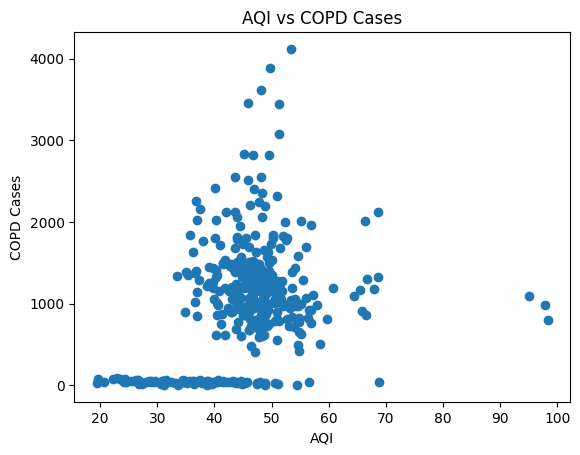

In [37]:
import matplotlib.pyplot as plt

plt.scatter(monthly_copd['AQI'], monthly_copd['copd_cases'])
plt.xlabel("AQI")
plt.ylabel("COPD Cases")
plt.title("AQI vs COPD Cases")
plt.show()

In [38]:
copd_daily = con.execute("""
SELECT 
    LOWER(REPLACE(TRIM(Region), ' ', '')) AS county,
    STRPTIME(Date, '%m/%d/%Y') AS date,
    COUNT(*) AS copd_cases
FROM 'master_filtered.parquet'
WHERE LOWER(CCDDCategory_flat) LIKE '%respiratory%'
GROUP BY county, date
ORDER BY county, date
""").df()

print(copd_daily.head())
print("Total rows:", copd_daily.shape)

      county       date  copd_cases
0  champaign 2017-01-01         126
1  champaign 2017-01-02          64
2  champaign 2017-01-03          50
3  champaign 2017-01-04          41
4  champaign 2017-01-05          59
Total rows: (43735, 3)


In [39]:
print(copd_daily['copd_cases'].describe())
print(copd_daily.isna().sum())

count    43735.000000
mean        14.640494
std         18.867804
min          1.000000
25%          3.000000
50%          6.000000
75%         20.000000
max        270.000000
Name: copd_cases, dtype: float64
county        0
date          0
copd_cases    0
dtype: int64


In [40]:
con.execute("""
SELECT COUNT(*)
FROM 'master_filtered.parquet'
WHERE LOWER(CCDDCategory_flat) LIKE '%respiratory%'
""").df()

,count_star()
0,640302


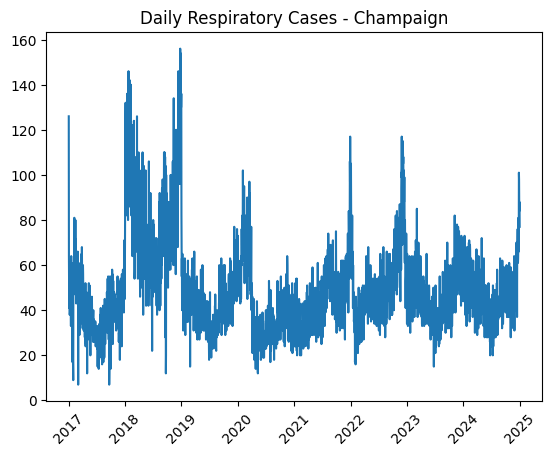

In [41]:
import matplotlib.pyplot as plt

subset = copd_daily[copd_daily['county'] == 'champaign']

plt.plot(subset['date'], subset['copd_cases'])
plt.title("Daily Respiratory Cases - Champaign")
plt.xticks(rotation=45)
plt.show()

In [42]:
import pandas as pd

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['county','date'])

In [43]:
# create lag features (1 day, 3 day, 7 day)
df['aqi_lag_1'] = df.groupby('county')['avg_aqi'].shift(1)
df['aqi_lag_3'] = df.groupby('county')['avg_aqi'].shift(3)
df['aqi_lag_7'] = df.groupby('county')['avg_aqi'].shift(7)

In [44]:
df['month'] = df['date'].dt.month

seasonality = df.groupby('month')[['cases','avg_aqi']].mean()
print(seasonality)

          cases    avg_aqi
month                     
1      3.598404  43.789362
2      3.556017  44.851215
3      3.478120  44.303620
4      3.162099  45.239067
5      3.227501  50.816098
6      2.929448  60.600613
7      2.824268  49.764495
8      3.228111  47.175115
9      3.617795  44.452154
10     3.796610  39.936970
11     3.592513  42.035829
12     3.487435  43.403665


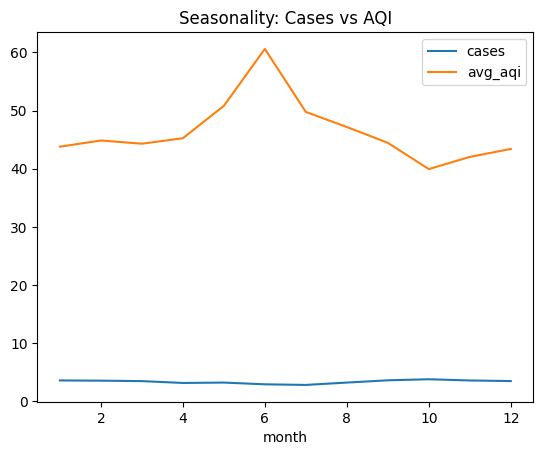

In [45]:
import matplotlib.pyplot as plt

seasonality.plot()
plt.title("Seasonality: Cases vs AQI")
plt.show()

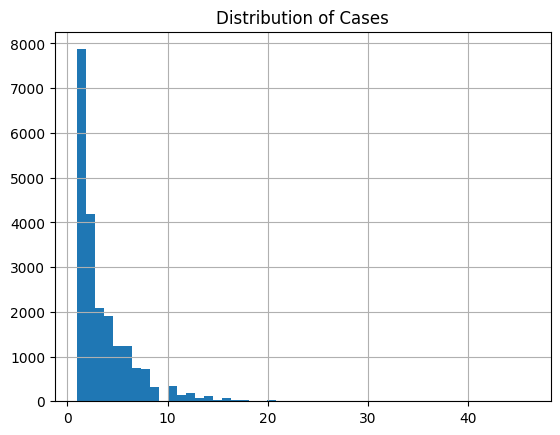

In [46]:
#normality check 
df['cases'].hist(bins=50)
plt.title("Distribution of Cases")
plt.show()

In [49]:
!pip install scipy
from scipy.stats import shapiro

sample = df['cases'].dropna().sample(5000)  # sample for speed
stat, p = shapiro(sample)

print("p-value:", p)

  Using cached scipy-1.17.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached scipy-1.17.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.2 MB)
p-value: 1.5524596920203754e-68


In [50]:
from scipy.stats import zscore

df['z_score'] = zscore(df['cases'].fillna(0))

anomalies = df[df['z_score'].abs() > 3]

print(anomalies[['county','date','cases']].head())

          county       date  cases
10014  champaign 2017-01-01     18
6739   champaign 2017-02-13     14
20138  champaign 2017-09-07     18
4799   champaign 2017-09-13     17
6789   champaign 2017-10-08     17


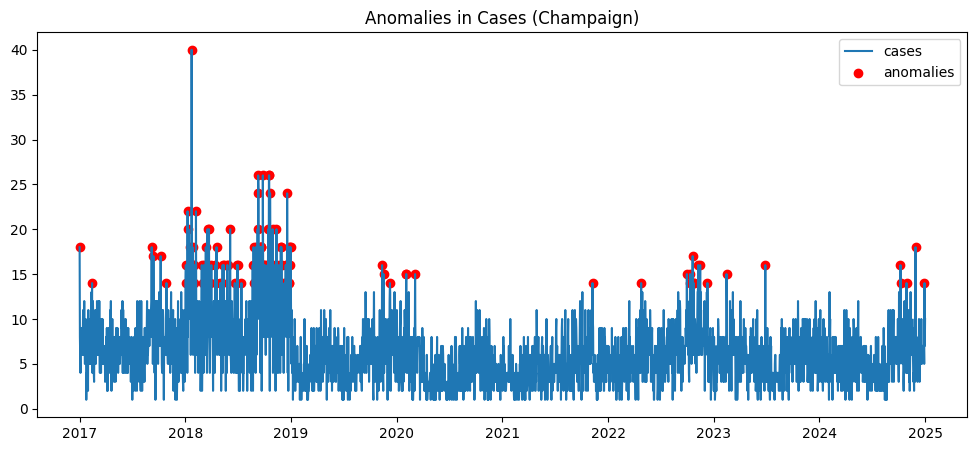

In [51]:
plt.figure(figsize=(12,5))

subset = df[df['county']=='champaign']

plt.plot(subset['date'], subset['cases'], label='cases')
plt.scatter(
    subset[subset['z_score'].abs()>3]['date'],
    subset[subset['z_score'].abs()>3]['cases'],
    color='red',
    label='anomalies'
)

plt.legend()
plt.title("Anomalies in Cases (Champaign)")
plt.show()

In [52]:
import pandas as pd

df = df.dropna()
df = df.sort_values(['county','date'])

# Create time features
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

# Lag features
df['aqi_lag_1'] = df.groupby('county')['avg_aqi'].shift(1)
df['aqi_lag_3'] = df.groupby('county')['avg_aqi'].shift(3)
df['cases_lag_1'] = df.groupby('county')['cases'].shift(1)

df = df.dropna()

In [53]:
X = df[['avg_aqi','avg_temp','avg_precip','aqi_lag_1','aqi_lag_3','cases_lag_1','month']]
y = df['cases']

In [54]:
split = int(len(df)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [57]:
!pip install scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
print("LR MAE:", mean_absolute_error(y_test, pred_lr))

  Using cached scikit_learn-1.8.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]
LR MAE: 1.5561324579054587


In [58]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
print("RF MAE:", mean_absolute_error(y_test, pred_rf))

RF MAE: 1.6588711194731889


In [60]:
!pip install xgboost
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)
print("XGB MAE:", mean_absolute_error(y_test, pred_xgb))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 140.9 MB/s  0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 137.8 MB/s  0:00:020:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]
XGB MAE: 1.6238603591918945


In [61]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)
print("DT MAE:", mean_absolute_error(y_test, pred_dt))

DT MAE: 2.20555032925682


In [62]:
results = {
    "Linear Regression": mean_absolute_error(y_test, pred_lr),
    "Random Forest": mean_absolute_error(y_test, pred_rf),
    "XGBoost": mean_absolute_error(y_test, pred_xgb),
    "Decision Tree": mean_absolute_error(y_test, pred_dt)
}

print(results)

{'Linear Regression': 1.5561324579054587, 'Random Forest': 1.6588711194731889, 'XGBoost': 1.6238603591918945, 'Decision Tree': 2.20555032925682}


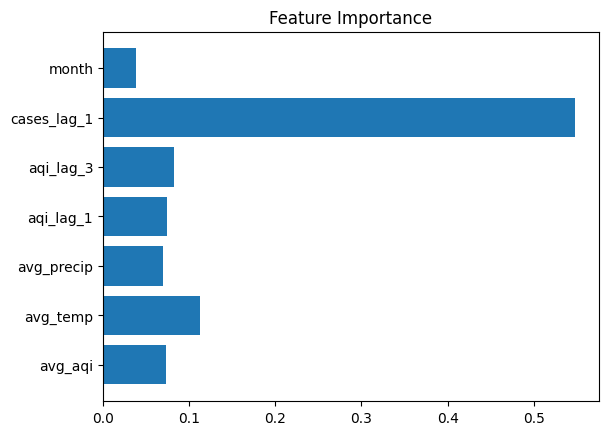

In [63]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

In [64]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [66]:
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [67]:
pred_gbr = gbr.predict(X_test)

In [70]:
import numpy as np
mae = mean_absolute_error(y_test, pred_gbr)

rmse = np.sqrt(mean_squared_error(y_test, pred_gbr))

print("Gradient Boosting MAE:", mae)
print("Gradient Boosting RMSE:", rmse)

Gradient Boosting MAE: 1.5853455708319084
Gradient Boosting RMSE: 2.183917293982284


In [71]:
results["Gradient Boosting"] = mae
print(results)

{'Linear Regression': 1.5561324579054587, 'Random Forest': 1.6588711194731889, 'XGBoost': 1.6238603591918945, 'Decision Tree': 2.20555032925682, 'Gradient Boosting': 1.5853455708319084}


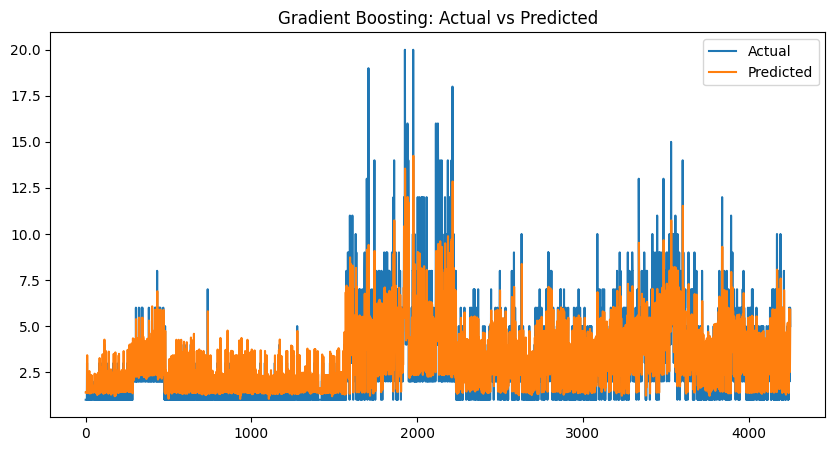

In [72]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(pred_gbr, label='Predicted')
plt.legend()
plt.title("Gradient Boosting: Actual vs Predicted")
plt.show()